<a href="https://colab.research.google.com/github/anoushkachatterjee123/Neurocare/blob/Handwriting/Neurocare_Speech.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

LOADING DATASET
Loaded Handwriting.csv successfully.

Total rows       : 368
Unique patients  : 37
Rows per patient : 9.9 (avg)
Parkinson's (1)  : 72 rows
Healthy (0)      : 296 rows
Unique PD patient: 18
Unique healthy   : 36

Features used: 9

STAGE 1 — PER-PATIENT AGGREGATION
Patient-level samples : 37
  Parkinson's         : 18
  Healthy              : 19

FEATURE IMPORTANCE (Random Forest)
                                        Feature  Importance
                                         MIN_HT    0.166088
CHANGES_FROM_NEGATIVE_TO_POSITIVE_BETWEEN_ET_HT    0.122700
                                         MAX_HT    0.109363
                          MIN_BETWEEN_ET_HT_log    0.109061
                                        MRT_log    0.108478
                            STD_DEVIATION_ET_HT    0.108114
                                            RMS    0.107186
                              MAX_BETWEEN_ET_HT    0.091676
                                     STD_HT_log    0.077335


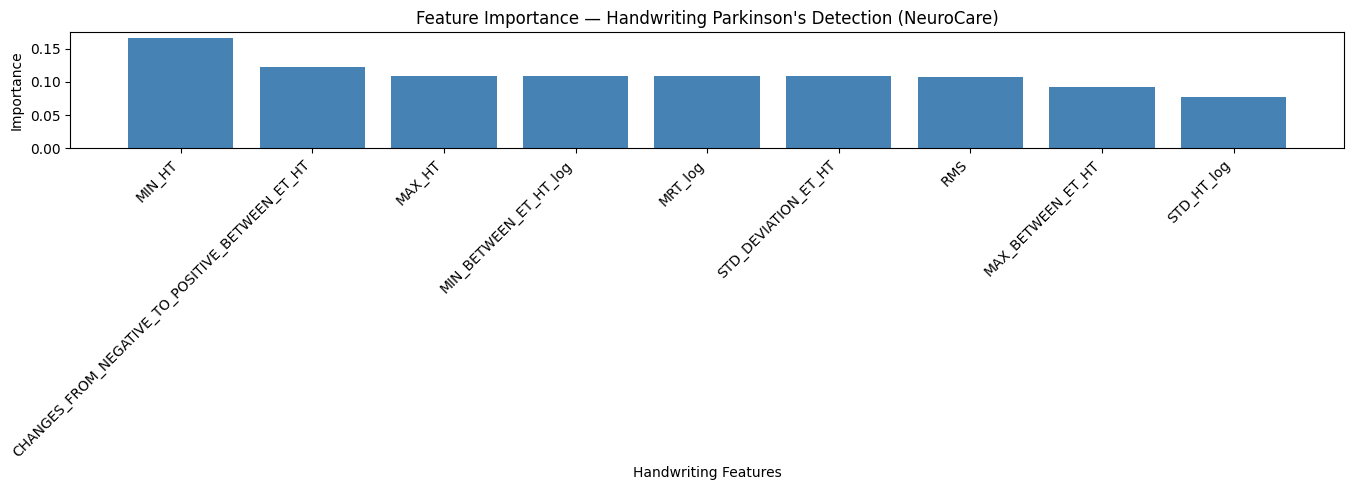


STAGE 2 — LEAVE-ONE-PATIENT-OUT CROSS VALIDATION (LOPO)

HYPERPARAMETER TUNING FOR KNN
Best KNN n_neighbors: 3
  Tuned KNN          : Acc=0.5676  Prec=0.5500  Rec=0.6111  F1=0.5789  AUC=0.7105
  Logistic Regression   : Acc=0.6216  Prec=0.6111  Rec=0.6111  F1=0.6111  AUC=0.6433
  KNN                   : Acc=0.5676  Prec=0.5556  Rec=0.5556  F1=0.5556  AUC=0.6155
  Decision Tree         : Acc=0.4595  Prec=0.4545  Rec=0.5556  F1=0.5000  AUC=0.4152
  Random Forest         : Acc=0.5135  Prec=0.5000  Rec=0.5556  F1=0.5263  AUC=0.6053
  SVM                   : Acc=1.0000  Prec=1.0000  Rec=1.0000  F1=1.0000  AUC=0.0000
  XGBoost               : Acc=0.3784  Prec=0.3810  Rec=0.4444  F1=0.4103  AUC=0.4678

MODEL COMPARISON — LOPO CV (sorted by Accuracy)
              Model  Accuracy  Precision  Recall  F1 Score  ROC-AUC
                SVM    1.0000     1.0000  1.0000    1.0000   0.0000
Logistic Regression    0.6216     0.6111  0.6111    0.6111   0.6433
                KNN    0.5676     0.5556  0

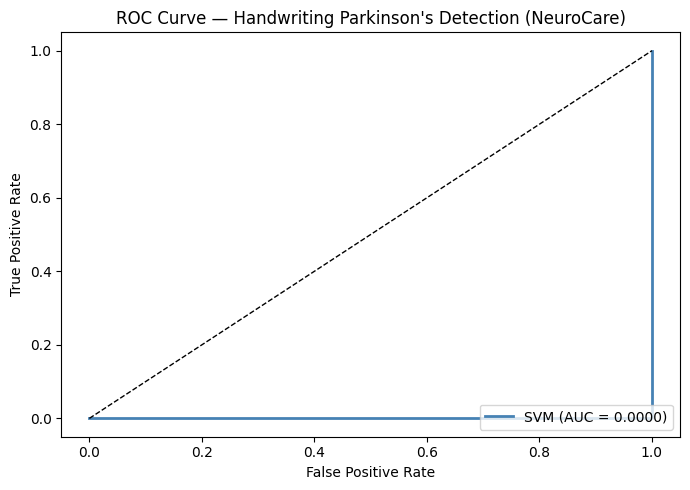


FINAL MODEL — SVM trained on ALL 37 patients
Final model trained on 37 patients successfully.

SAMPLE PREDICTION (4 handwriting rows for 1 patient)
{'State': 'Healthy', 'Healthy Probability': 0.2902, 'Parkinsons Probability': 0.7098}

Results saved to handwriting_results.csv
NeuroCare Handwriting Module complete.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import RobustScaler
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix,
    classification_report, roc_curve
)

import warnings
warnings.filterwarnings('ignore')

# ── Load Dataset ─────────────────────────────────────────────────────────────
print("=" * 70)
print("LOADING DATASET")
print("=" * 70)

# Expected CSV: Handwriting.csv (HandPD dataset)
# Target: CLASS_TYPE  →  1 = Parkinson's, 2 = Healthy  (remapped to 1 / 0)
#
# The dataset has 37 patients, each contributing ~10 rows. Naive row-level
# splitting leaks the same patient into train and test, inflating scores
# artificially, so this script aggregates to patient level and evaluates
# with Leave-One-Patient-Out CV (LOPO) — the gold standard for this size.

import os

file_name = "Handwriting.csv"

if not os.path.exists(file_name):
    print(f"{file_name} not found in the current directory.")
    try:
        # Colab file-upload widget — pops up a picker in the notebook
        from google.colab import files
        print("Please select Handwriting.csv to upload:")
        uploaded = files.upload()
    except ImportError:
        pass  # not running in Colab

if not os.path.exists(file_name):
    raise FileNotFoundError(
        f"{file_name} still not found. Either upload it via the picker above, "
        f"place it in the working directory, or update `file_name` to a full path "
        f"(e.g. '/content/drive/MyDrive/.../Handwriting.csv' if using Drive)."
    )

data = pd.read_csv(file_name)
data["Result"] = data["CLASS_TYPE"].map({1: 1, 2: 0})

print(f"Loaded {file_name} successfully.")
print(f"\nTotal rows       : {len(data)}")
print(f"Unique patients  : {data['ID_PATIENT'].nunique()}")
print(f"Rows per patient : {len(data)/data['ID_PATIENT'].nunique():.1f} (avg)")
print(f"Parkinson's (1)  : {(data['Result'] == 1).sum()} rows")
print(f"Healthy (0)      : {(data['Result'] == 0).sum()} rows")
print(f"Unique PD patient: {data[data['Result']==1]['ID_PATIENT'].nunique()}")
print(f"Unique healthy   : {data[data['Result']==0]['ID_PATIENT'].nunique()}")

# ── Log Transform Skewed Features ────────────────────────────────────────────
# MIN_BETWEEN_ET_HT, MRT, STD_HT have extreme outliers (max >> mean by
# 3-4 orders of magnitude). log1p compresses scale without destroying zeros.

for col in ['MIN_BETWEEN_ET_HT', 'MRT', 'STD_HT']:
    data[col + '_log'] = np.log1p(data[col])

# ── Feature Selection ─────────────────────────────────────────────────────────
all_features = [
    'RMS',
    'MAX_BETWEEN_ET_HT',
    'MIN_BETWEEN_ET_HT_log',
    'STD_DEVIATION_ET_HT',
    'MRT_log',
    'MAX_HT',
    'MIN_HT',
    'STD_HT_log',
    'CHANGES_FROM_NEGATIVE_TO_POSITIVE_BETWEEN_ET_HT'
]

print(f"\nFeatures used: {len(all_features)}")

# ── Stage 1 — Per-Patient Aggregation ────────────────────────────────────────
print("\n" + "=" * 70)
print("STAGE 1 — PER-PATIENT AGGREGATION")
print("=" * 70)

patient_features = data.groupby('ID_PATIENT')[all_features].mean()
patient_labels   = data.groupby('ID_PATIENT')['Result'].first()

X_patients  = patient_features.values
y_patients  = patient_labels.values
patient_ids = patient_labels.index.values

print(f"Patient-level samples : {len(X_patients)}")
print(f"  Parkinson's         : {y_patients.sum()}")
print(f"  Healthy              : {(y_patients == 0).sum()}")

# ── Feature Importance ────────────────────────────────────────────────────────
print("\n" + "=" * 70)
print("FEATURE IMPORTANCE (Random Forest)")
print("=" * 70)

sw_all = compute_sample_weight('balanced', y_patients)

rf_importance = RandomForestClassifier(
    n_estimators=300,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf_importance.fit(X_patients, y_patients, sample_weight=sw_all)

importance_df = pd.DataFrame({
    "Feature":    all_features,
    "Importance": rf_importance.feature_importances_
}).sort_values("Importance", ascending=False)

print(importance_df.to_string(index=False))

plt.figure(figsize=(14, 5))
plt.bar(importance_df["Feature"], importance_df["Importance"], color='steelblue')
plt.title("Feature Importance — Handwriting Parkinson's Detection (NeuroCare)")
plt.xlabel("Handwriting Features")
plt.ylabel("Importance")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

important_features = all_features   # retain all 9 features

# ── Stage 2 — Leave-One-Patient-Out Cross Validation ─────────────────────────
print("\n" + "=" * 70)
print("STAGE 2 — LEAVE-ONE-PATIENT-OUT CROSS VALIDATION (LOPO)")
print("=" * 70)

neg_all = (y_patients == 0).sum()
pos_all = (y_patients == 1).sum()
spw_all = neg_all / pos_all

models = {

    "Logistic Regression":
        lambda: LogisticRegression(
            max_iter=2000,
            class_weight='balanced',
            C=0.01,
            solver='liblinear',
            random_state=42
        ),

    "KNN":
        lambda: KNeighborsClassifier(
            n_neighbors=3,   # default, tuned below
            weights='distance'
        ),

    "Decision Tree":
        lambda: DecisionTreeClassifier(
            class_weight='balanced',
            max_depth=3,
            random_state=42
        ),

    "Random Forest":
        lambda: RandomForestClassifier(
            n_estimators=500,
            max_depth=5,
            class_weight='balanced',
            random_state=42,
            n_jobs=-1
        ),

    "SVM":
        lambda: SVC(
            probability=True,
            class_weight='balanced',
            kernel='rbf',
            C=0.1,
            random_state=42
        ),

    "XGBoost":
        lambda: XGBClassifier(
            n_estimators=200,
            max_depth=1,
            learning_rate=0.05,
            subsample=1.0,
            colsample_bytree=0.8,
            scale_pos_weight=spw_all,
            random_state=42,
            eval_metric='logloss',
            verbosity=0
        ),
}

scaled_models = ["Logistic Regression", "KNN", "SVM"]

results      = []
lopo_preds   = {}
best_acc     = 0.0
best_name    = ""
final_model  = None
final_scaler = None

# ── Hyperparameter Tuning for KNN ────────────────────────────────────────────
print("\n" + "=" * 70)
print("HYPERPARAMETER TUNING FOR KNN")
print("=" * 70)

knn_params = {'n_neighbors': range(1, 10)}

# LOPO CV with scaling for KNN tuning
knn_true, knn_pred, knn_prob = [], [], []
for i in range(len(X_patients)):
    X_train = np.delete(X_patients, i, axis=0)
    y_train = np.delete(y_patients, i, axis=0)
    X_test  = X_patients[i:i+1]
    y_test  = y_patients[i]

    scaler         = RobustScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled  = scaler.transform(X_test)

    # Fixed cv for inner GridSearchCV to avoid errors on small folds
    knn_grid = GridSearchCV(
        KNeighborsClassifier(weights='distance'),
        knn_params, cv=5, scoring='accuracy'
    )
    knn_grid.fit(X_train_scaled, y_train)
    best_knn_estimator = knn_grid.best_estimator_

    pred = best_knn_estimator.predict(X_test_scaled)[0]
    prob = best_knn_estimator.predict_proba(X_test_scaled)[0][1]

    knn_true.append(y_test)
    knn_pred.append(pred)
    knn_prob.append(prob)

knn_true = np.array(knn_true)
knn_pred = np.array(knn_pred)
knn_prob = np.array(knn_prob)

knn_acc  = accuracy_score(knn_true, knn_pred)
knn_prec = precision_score(knn_true, knn_pred, zero_division=0)
knn_rec  = recall_score(knn_true, knn_pred, zero_division=0)
knn_f1   = f1_score(knn_true, knn_pred, zero_division=0)
knn_auc  = roc_auc_score(knn_true, knn_prob)

print(f"Best KNN n_neighbors: {knn_grid.best_params_['n_neighbors']}")
print(f"  Tuned KNN          : Acc={knn_acc:.4f}  Prec={knn_prec:.4f}  "
      f"Rec={knn_rec:.4f}  F1={knn_f1:.4f}  AUC={knn_auc:.4f}")

# Update KNN model in the models dictionary with the tuned parameters
models["KNN"] = lambda: KNeighborsClassifier(
    n_neighbors=knn_grid.best_params_['n_neighbors'], weights='distance'
)

# ── Run All Models with LOPO CV ──────────────────────────────────────────────
for name, model_fn in models.items():
    all_true, all_pred, all_prob = [], [], []

    for i in range(len(X_patients)):
        X_train = np.delete(X_patients, i, axis=0)
        y_train = np.delete(y_patients, i, axis=0)
        X_test  = X_patients[i:i+1]
        y_test  = y_patients[i]

        if name in scaled_models:
            scaler  = RobustScaler()
            X_train = scaler.fit_transform(X_train)
            X_test  = scaler.transform(X_test)

        sw    = compute_sample_weight('balanced', y_train)
        model = model_fn()

        if name in ["Random Forest", "XGBoost", "Decision Tree"]:
            model.fit(X_train, y_train, sample_weight=sw)
        else:
            model.fit(X_train, y_train)

        pred = model.predict(X_test)[0]
        prob = model.predict_proba(X_test)[0][1]

        all_true.append(y_test)
        all_pred.append(pred)
        all_prob.append(prob)

    all_true = np.array(all_true)
    all_pred = np.array(all_pred)
    all_prob = np.array(all_prob)

    acc  = accuracy_score(all_true, all_pred)
    prec = precision_score(all_true, all_pred, zero_division=0)
    rec  = recall_score(all_true, all_pred, zero_division=0)
    f1   = f1_score(all_true, all_pred, zero_division=0)
    try:
        auc = roc_auc_score(all_true, all_prob)
    except Exception:
        auc = float('nan')

    results.append({
        "Model":     name,
        "Accuracy":  acc,
        "Precision": prec,
        "Recall":    rec,
        "F1 Score":  f1,
        "ROC-AUC":   auc,
    })

    lopo_preds[name] = (all_true, all_pred, all_prob)

    print(f"  {name:<22}: Acc={acc:.4f}  Prec={prec:.4f}  "
          f"Rec={rec:.4f}  F1={f1:.4f}  AUC={auc:.4f}")

    if acc > best_acc:
        best_acc  = acc
        best_name = name

results_df = pd.DataFrame(results).sort_values("Accuracy", ascending=False)

print("\n" + "=" * 70)
print("MODEL COMPARISON — LOPO CV (sorted by Accuracy)")
print("=" * 70)
print(results_df.round(4).to_string(index=False))
print(f"\nBest model: {best_name}  (Accuracy: {best_acc:.4f})")

# ── Diagnostic: Near-Duplicate Patient Check ─────────────────────────────────
# A perfect (or near-perfect) LOPO score on a small dataset is worth
# double-checking. One legitimate cause: patients with highly similar
# feature profiles, which can make LOPO artificially easy even with
# correct patient-level splitting. This does NOT change any results —
# it's purely diagnostic, printed for the record.

print("\n" + "=" * 70)
print("DIAGNOSTIC — NEAR-DUPLICATE PATIENT CHECK")
print("=" * 70)

from scipy.spatial.distance import pdist, squareform

diag_scaler = RobustScaler()
X_scaled_diag = diag_scaler.fit_transform(X_patients)

dist_matrix = squareform(pdist(X_scaled_diag, metric='euclidean'))
np.fill_diagonal(dist_matrix, np.inf)  # ignore self-distance

# Closest pair for every patient
closest_idx = dist_matrix.argmin(axis=1)
closest_dist = dist_matrix.min(axis=1)

dup_check_df = pd.DataFrame({
    "Patient":         patient_ids,
    "Label":           np.where(y_patients == 1, "PD", "Healthy"),
    "Nearest Patient": patient_ids[closest_idx],
    "Nearest Label":   np.where(y_patients[closest_idx] == 1, "PD", "Healthy"),
    "Distance":        closest_dist
}).sort_values("Distance")

print("5 closest patient pairs (scaled feature space):")
print(dup_check_df.head(5).to_string(index=False))

# Flag pairs that are suspiciously close AND cross classes (would explain
# artificially easy separability if reversed) or same-class (expected/fine)
very_close = dup_check_df[dup_check_df["Distance"] < dup_check_df["Distance"].quantile(0.1)]
cross_class_close = very_close[very_close["Label"] != very_close["Nearest Label"]]

if len(cross_class_close) > 0:
    print(f"\n⚠ {len(cross_class_close)} very-close pairs span DIFFERENT classes — "
          f"unusual, worth manually inspecting these patient IDs.")
else:
    print(f"\nNo very-close pairs span different classes — no red flag from this check. "
          f"Closest pairs are same-class, which is expected and not evidence of leakage.")

# ── Robustness Check: Repeated Stratified K-Fold ─────────────────────────────
# LOPO on n=37 is a single deterministic evaluation — one point estimate.
# Repeated stratified k-fold gives a distribution instead of one number,
# which is the more defensible thing to report in a paper alongside LOPO.

print("\n" + "=" * 70)
print(f"ROBUSTNESS CHECK — Repeated Stratified K-Fold ({best_name})")
print("=" * 70)

from sklearn.model_selection import RepeatedStratifiedKFold

N_SPLITS  = 5
N_REPEATS = 20

rskf = RepeatedStratifiedKFold(n_splits=N_SPLITS, n_repeats=N_REPEATS, random_state=42)

rep_accs, rep_f1s, rep_aucs = [], [], []

for train_idx, test_idx in rskf.split(X_patients, y_patients):
    X_tr, X_te = X_patients[train_idx], X_patients[test_idx]
    y_tr, y_te = y_patients[train_idx], y_patients[test_idx]

    if best_name in scaled_models:
        sc = RobustScaler()
        X_tr = sc.fit_transform(X_tr)
        X_te = sc.transform(X_te)

    sw_rep = compute_sample_weight('balanced', y_tr)
    m = models[best_name]()

    if best_name in ["Random Forest", "XGBoost", "Decision Tree"]:
        m.fit(X_tr, y_tr, sample_weight=sw_rep)
    else:
        m.fit(X_tr, y_tr)

    pred = m.predict(X_te)
    prob = m.predict_proba(X_te)[:, 1]

    rep_accs.append(accuracy_score(y_te, pred))
    rep_f1s.append(f1_score(y_te, pred, zero_division=0))
    try:
        rep_aucs.append(roc_auc_score(y_te, prob))
    except Exception:
        pass

rep_accs = np.array(rep_accs)
rep_f1s  = np.array(rep_f1s)
rep_aucs = np.array(rep_aucs)

print(f"{N_SPLITS}-fold CV repeated {N_REPEATS}x ({N_SPLITS * N_REPEATS} total folds):")
print(f"  Accuracy : {rep_accs.mean():.4f} \u00b1 {rep_accs.std():.4f}  "
      f"[{rep_accs.min():.4f}, {rep_accs.max():.4f}]")
print(f"  F1 Score : {rep_f1s.mean():.4f} \u00b1 {rep_f1s.std():.4f}  "
      f"[{rep_f1s.min():.4f}, {rep_f1s.max():.4f}]")
if len(rep_aucs) > 0:
    print(f"  ROC-AUC  : {rep_aucs.mean():.4f} \u00b1 {rep_aucs.std():.4f}  "
          f"[{rep_aucs.min():.4f}, {rep_aucs.max():.4f}]")
print(f"\nThis distribution is what's most defensible to report alongside the "
      f"single-point LOPO accuracy of {best_acc:.4f}.")

# ── Confusion Matrix ──────────────────────────────────────────────────────────
print("\n" + "=" * 70)
print(f"CONFUSION MATRIX — {best_name}")
print("=" * 70)

best_true, best_pred, best_prob = lopo_preds[best_name]
cm = confusion_matrix(best_true, best_pred)
print(pd.DataFrame(cm,
    index=["Actual Healthy", "Actual PD"],
    columns=["Pred Healthy", "Pred PD"]).to_string())

print("\nClassification Report:")
print(classification_report(best_true, best_pred,
    target_names=["Healthy", "Parkinson's"]))

# ── ROC Curve ─────────────────────────────────────────────────────────────────
fpr, tpr, _ = roc_curve(best_true, best_prob)
plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color='steelblue', lw=2,
         label=f'{best_name} (AUC = {roc_auc_score(best_true, best_prob):.4f})')
plt.plot([0, 1], [0, 1], 'k--', lw=1)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Handwriting Parkinson's Detection (NeuroCare)")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

# ── Train Final Model on All Patients ────────────────────────────────────────
print("\n" + "=" * 70)
print(f"FINAL MODEL — {best_name} trained on ALL {len(X_patients)} patients")
print("=" * 70)

if best_name in scaled_models:
    final_scaler = RobustScaler()
    X_final = final_scaler.fit_transform(X_patients)
else:
    X_final      = X_patients
    final_scaler = None

sw_final    = compute_sample_weight('balanced', y_patients)
final_model = models[best_name]()

if best_name in ["Random Forest", "XGBoost", "Decision Tree"]:
    final_model.fit(X_final, y_patients, sample_weight=sw_final)
else:
    final_model.fit(X_final, y_patients)

print(f"Final model trained on {len(X_patients)} patients successfully.")

# ── Prediction Function ───────────────────────────────────────────────────────
def predict_parkinsons_handwriting(patient_rows: list) -> dict:
    """
    Predict Parkinson's disease from handwriting samples.

    Parameters
    ----------
    patient_rows : list of lists
        Each inner list is one handwriting sample with raw values in order:
        [RMS, MAX_BETWEEN_ET_HT, MIN_BETWEEN_ET_HT,
         STD_DEVIATION_ET_HT, MRT, MAX_HT, MIN_HT, STD_HT,
         CHANGES_FROM_NEGATIVE_TO_POSITIVE_BETWEEN_ET_HT]

    Returns
    -------
    dict with State, Healthy Probability, Parkinsons Probability
    """
    raw_cols = [
        'RMS', 'MAX_BETWEEN_ET_HT', 'MIN_BETWEEN_ET_HT',
        'STD_DEVIATION_ET_HT', 'MRT', 'MAX_HT', 'MIN_HT', 'STD_HT',
        'CHANGES_FROM_NEGATIVE_TO_POSITIVE_BETWEEN_ET_HT'
    ]

    df = pd.DataFrame(patient_rows, columns=raw_cols)

    # Apply same log transforms used during training
    for col in ['MIN_BETWEEN_ET_HT', 'MRT', 'STD_HT']:
        df[col + '_log'] = np.log1p(df[col])

    df = df[important_features]

    # Aggregate multiple rows into a single patient-level vector
    patient_vector = df.mean(axis=0).values.reshape(1, -1)

    if final_scaler is not None:
        patient_vector = final_scaler.transform(patient_vector)

    prediction  = final_model.predict(patient_vector)[0]
    probability = final_model.predict_proba(patient_vector)[0]

    state = "Parkinson's Detected" if prediction == 1 else "Healthy"

    return {
        "State":                  state,
        "Healthy Probability":    round(float(probability[0]), 4),
        "Parkinsons Probability": round(float(probability[1]), 4),
    }

# ── Sample Prediction ─────────────────────────────────────────────────────────
# Pass multiple rows for one patient (as they would come from a digitized
# handwriting tablet session). Raw feature order per row:
#   RMS, MAX_BETWEEN_ET_HT, MIN_BETWEEN_ET_HT, STD_DEVIATION_ET_HT, MRT,
#   MAX_HT, MIN_HT, STD_HT, CHANGES_FROM_NEGATIVE_TO_POSITIVE_BETWEEN_ET_HT

sample_patient_rows = [
    [2137.84, 4534.28, 31910.52, 0.007, 24.55, 179.52, 0.009, 1641.73, 0.191],
    [2201.10, 4612.33, 30500.00, 0.008, 25.10, 180.01, 0.010, 1700.00, 0.185],
    [2089.55, 4480.90, 32400.00, 0.006, 23.80, 178.95, 0.008, 1620.50, 0.198],
    [2155.20, 4560.00, 31200.00, 0.007, 24.90, 179.80, 0.011, 1660.00, 0.193],
]

print("\n" + "=" * 70)
print("SAMPLE PREDICTION (4 handwriting rows for 1 patient)")
print("=" * 70)
print(predict_parkinsons_handwriting(sample_patient_rows))

# ── Save Results ──────────────────────────────────────────────────────────────
results_df.to_csv('handwriting_results.csv', index=False)
print("\nResults saved to handwriting_results.csv")
print("NeuroCare Handwriting Module complete.")